In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Importar / Traer los datos

In [194]:
prestamos = pd.read_csv('loan_data.csv')
prestamos

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [195]:
prestamos.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

## 2. EDA Analisis exploratorio de datos

In [196]:
## Si hay duplicados?
print("Cantidad de datos duplicados:", prestamos.duplicated().sum())
## Si hay nulos?
print("Cantidad de datos nulos por columna:")
display(prestamos.isnull().sum())

Cantidad de datos duplicados: 0
Cantidad de datos nulos por columna:


person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


loan_status
0    35000
1    10000
Name: count, dtype: int64

<Axes: xlabel='loan_status'>

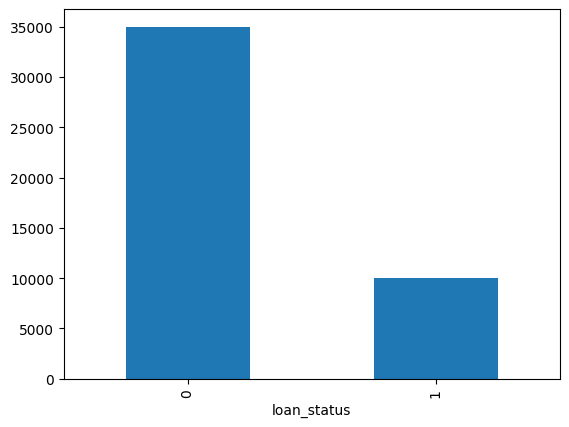

In [197]:
# ## Mirar si estan balanceados

display(prestamos.describe())
display(prestamos['loan_status'].value_counts())
prestamos['loan_status'].value_counts().plot(kind='bar')

<Axes: xlabel='credit_score', ylabel='loan_amnt'>

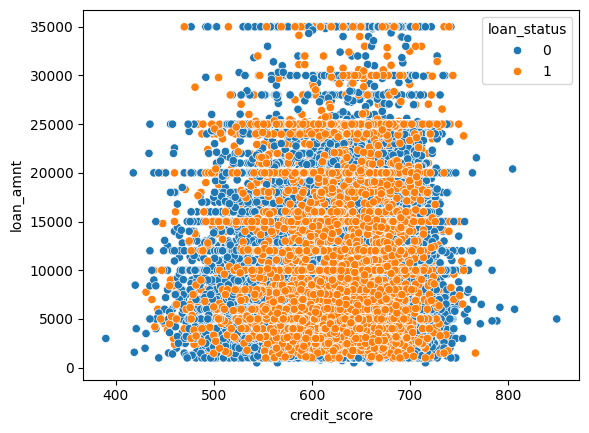

In [198]:
## Analisis bivariado de cantidad del prestamo vs puntaje crediticio
sns.scatterplot(x='credit_score', y='loan_amnt', data=prestamos, hue = 'loan_status')

count    45000.000000
mean        27.764178
std          6.045108
min         20.000000
25%         24.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

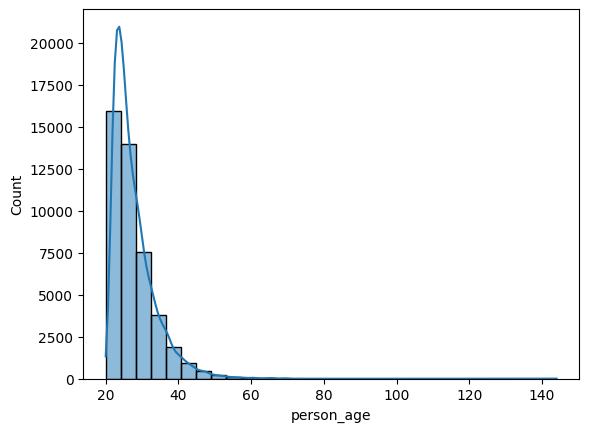

In [199]:
## Histograma de edades de los clientes
sns.histplot(prestamos['person_age'], bins=30, kde=True)

prestamos['person_age'].describe()

<Axes: xlabel='loan_status', ylabel='person_age'>

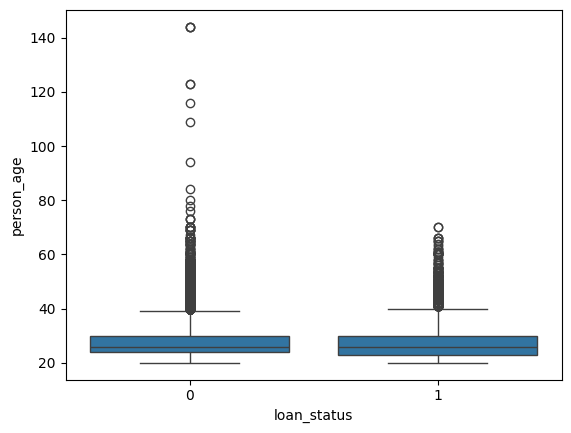

In [200]:
## Existe una relación entre la edad y la aprobacion del prestamo?
sns.boxplot(x='loan_status', y='person_age', data=prestamos)

<Axes: xlabel='credit_score', ylabel='person_age'>

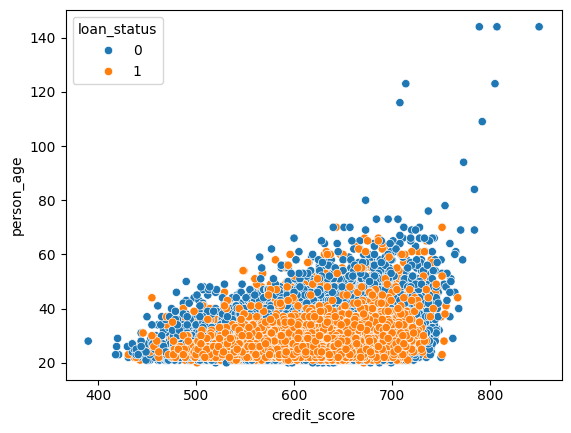

In [201]:
## Mirar la relacion entre edad y score crediticio  
sns.scatterplot(x='credit_score', y='person_age', data=prestamos, hue = 'loan_status')

## 3. Limpieza / Preprocesamiento de datos

0. Separar los conjuntos de entrenamiento y prueba
1. Eliminación de los datos de las personas con edades mayores a 90 años
2. Balancear los datos
3. Codificación de variables categoricas --> One Hot Encoding, Target Encoding, Frecuency Encoding, Ordinal Encoding


In [202]:
prestamos_copy = prestamos.copy()


## Separacion de datos en entrenamiento y prueba 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(prestamos_copy.drop('loan_status', axis=1), prestamos_copy['loan_status'], test_size=0.2, random_state=42)


## Eliminacion de edades demasiado avanzadas
X_train = X_train[X_train['person_age'] < 90]  ## elimino 8 datos
y_train = y_train[X_train.index]  ## elimino los mismos 8 datos del target

In [203]:
## Balanceo de los datos ---> Balanceo  Hibrido --> Oversampling a la clase minoritaria + Undersampling a la clase mayoritaria
from imblearn.over_sampling import RandomOverSampler 
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline  

cantidad_datos_esperada = int(y_train.count()/2)

# Definir las estrategias de sobremuestreo y submuestreo
oversample_strategy = {1:cantidad_datos_esperada}
undersample_strategy = {0:cantidad_datos_esperada}

oversample = RandomOverSampler(sampling_strategy=oversample_strategy, random_state=42)
undersample = RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=42)


# Pipeline que une las dos técnicas de balanceo
hybrid_pipeline = Pipeline(steps=[
    ('oversample', oversample),
    ('undersample', undersample)
])

# Aplicar el pipeline de balanceo a los datos
X_train_balanced, y_train_balanced = hybrid_pipeline.fit_resample(X_train, y_train)

print(X_train_balanced.shape, y_train_balanced.value_counts())   


(35994, 13) loan_status
0    17997
1    17997
Name: count, dtype: int64


In [204]:
X_train_balanced

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
2774,26.0,male,High School,111152.0,4,RENT,14200.0,PERSONAL,10.99,0.13,3.0,660,Yes
3258,48.0,male,Bachelor,80016.0,23,MORTGAGE,12475.0,HOMEIMPROVEMENT,6.62,0.16,11.0,712,No
23536,32.0,male,Associate,42950.0,11,RENT,5500.0,PERSONAL,11.49,0.13,5.0,682,Yes
34822,28.0,male,Associate,96382.0,6,MORTGAGE,16425.0,PERSONAL,7.90,0.17,10.0,535,Yes
3550,29.0,male,High School,101427.0,7,RENT,8000.0,MEDICAL,11.49,0.08,8.0,624,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45996,23.0,male,Bachelor,41882.0,3,RENT,15000.0,EDUCATION,11.71,0.36,4.0,657,No
45997,23.0,female,High School,107265.0,0,MORTGAGE,8038.0,DEBTCONSOLIDATION,14.08,0.07,4.0,619,No
45998,24.0,female,Master,40411.0,0,RENT,13300.0,DEBTCONSOLIDATION,7.66,0.33,4.0,578,No
45999,33.0,male,Bachelor,54974.0,8,RENT,6800.0,EDUCATION,11.22,0.12,6.0,627,No


In [205]:
## Codificacion de las variables categoricas  

## OneHotEncoder: usar cuando la variable categorica no tiene muchas categorias y no hay un orden intrinseco entre ellas. 
## Crea una nueva columna para cada categoria, asignando un 1 a la categoria presente y un 0 a las ausentes. 
## Esto evita introducir relaciones de orden que no existen entre las categorias.
from sklearn.preprocessing import OneHotEncoder

person_gender_encoder = OneHotEncoder(sparse_output=False)  ## drop='first' para evitar la trampa de las variables ficticias
person_gender_encoded = person_gender_encoder.fit_transform(X_train_balanced[['person_gender','loan_intent', 'person_education','person_home_ownership', 'previous_loan_defaults_on_file']])


X_train_balanced_numeric = X_train_balanced.merge(pd.DataFrame(person_gender_encoded, columns=person_gender_encoder.get_feature_names_out(['person_gender','loan_intent', 'person_education','person_home_ownership', 'previous_loan_defaults_on_file']), index=X_train_balanced.index), left_index=True, right_index=True) 
X_train_balanced_numeric = X_train_balanced_numeric.drop(['person_gender','loan_intent', 'person_education','person_home_ownership', 'previous_loan_defaults_on_file'], axis=1)
X_train_balanced_numeric

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
2774,26.0,111152.0,4,14200.0,10.99,0.13,3.0,660,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3258,48.0,80016.0,23,12475.0,6.62,0.16,11.0,712,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
23536,32.0,42950.0,11,5500.0,11.49,0.13,5.0,682,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
34822,28.0,96382.0,6,16425.0,7.90,0.17,10.0,535,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3550,29.0,101427.0,7,8000.0,11.49,0.08,8.0,624,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45996,23.0,41882.0,3,15000.0,11.71,0.36,4.0,657,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
45997,23.0,107265.0,0,8038.0,14.08,0.07,4.0,619,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
45998,24.0,40411.0,0,13300.0,7.66,0.33,4.0,578,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
45999,33.0,54974.0,8,6800.0,11.22,0.12,6.0,627,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
X_train_balanced    

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
2774,26.0,male,High School,111152.0,4,RENT,14200.0,PERSONAL,10.99,0.13,3.0,660,Yes
3258,48.0,male,Bachelor,80016.0,23,MORTGAGE,12475.0,HOMEIMPROVEMENT,6.62,0.16,11.0,712,No
23536,32.0,male,Associate,42950.0,11,RENT,5500.0,PERSONAL,11.49,0.13,5.0,682,Yes
34822,28.0,male,Associate,96382.0,6,MORTGAGE,16425.0,PERSONAL,7.90,0.17,10.0,535,Yes
3550,29.0,male,High School,101427.0,7,RENT,8000.0,MEDICAL,11.49,0.08,8.0,624,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45996,23.0,male,Bachelor,41882.0,3,RENT,15000.0,EDUCATION,11.71,0.36,4.0,657,No
45997,23.0,female,High School,107265.0,0,MORTGAGE,8038.0,DEBTCONSOLIDATION,14.08,0.07,4.0,619,No
45998,24.0,female,Master,40411.0,0,RENT,13300.0,DEBTCONSOLIDATION,7.66,0.33,4.0,578,No
45999,33.0,male,Bachelor,54974.0,8,RENT,6800.0,EDUCATION,11.22,0.12,6.0,627,No


In [207]:
### TargetEncoding: usar cuando la variable categorica tiene muchas categorias o hay un orden intrinseco entre ellas.
## Asigna a cada categoria el valor promedio del target para esa categoria.
## Me sirve cuando la variable categorica tiene alta relacion con la variable objetivo, pero puede introducir ruido si hay categorias con pocos datos o si la relacion no es fuerte.

import numpy as np
from sklearn.preprocessing import TargetEncoder
X_train_balanced.merge(y_train_balanced, left_index=True, right_index=True)[['loan_intent', 'loan_status']].groupby('loan_intent').mean()

,loan_status
loan_intent,
DEBTCONSOLIDATION,0.600638
EDUCATION,0.423589
HOMEIMPROVEMENT,0.550990
MEDICAL,0.574051
PERSONAL,0.472001
VENTURE,0.365929


In [208]:
## FrecuencyEncoding: asigna a cada categoria la frecuencia con la que aparece en el dataset.
# Es una tecnica simple pero puede ser efectiva cuando la frecuencia de las categorias tiene relacion con la variable objetivo.
# Sin embargo, puede introducir ruido si hay categorias con pocos datos o si la relacion no es fuerte.

X_train_balanced.merge(y_train_balanced, left_index=True, right_index=True)[['loan_intent', 'person_age']].groupby('loan_intent').count()


,person_age
loan_intent,
DEBTCONSOLIDATION,6578
EDUCATION,6766
HOMEIMPROVEMENT,4040
MEDICAL,7353
PERSONAL,5786
VENTURE,5471
